# Terrestrial Laser Scanning Test Case

This notebook gives a brief overview over TLS occlusion mapping using OccPy.
The last Cell shows you how to execute the script from the command line using a JSON config file. 

First we import the relevant modules.

In [1]:
from occpy.OccPy import OccPy
from occpy import TerrainModel
import os
from pathlib import Path

We now set our root folder to the folder where our data is stored.
We can now set the input parameters and read the trajectory file.

In [2]:
root_folder = Path("C:/Users/an274/december/OccPy/data/TLS/")

test = OccPy(laz_in=os.path.join(root_folder, "LAZ"),
             out_dir=os.path.join(str(root_folder.parent.parent), "output"),
             vox_dim=0.1,
             lower_threshold=1,
             points_per_iter=100000000,
             plot_dim=[2676541,
                       1246160,
                       540,
                       2676591,
                       1246210,
                       615])

test.read_sensorpos_file(path2senspos=os.path.join(root_folder, "ScanPositions.txt"),
                         delimiter=" ",
                         hdr_scanpos_id="ScanPosID",
                         hdr_x="X",
                         hdr_y="Y",
                         hdr_z="Z",
                         str_idx_ScanPosID=23,
                         sens_pos_id_offset=1,  # This is a very specific use case, where we had an offset of scan pos id between laz files and scan pos id in the scanner position file.
                         single_return=True)

Now we can start the raytracing and save the outputs.

In [3]:
test.do_raytracing()

###############################
##### Processing Rameren_FP05_FP07_FP08-10_rot2LV95.laz...
###############################
Extracting Nhit
Elapsed Time: 10.40 seconds
Extracting Nocc
Elapsed Time: 10.77 seconds
Extracting Nmiss
Elapsed Time: 10.36 seconds
Saving Occlusion Outputs
Elapsed Time: 2.69 seconds
Classify Grid
Elapsed Time: 4.849318265914917 seconds


Before we derive statistics and plot the results, we need to normalize the height using a digital terrain model and a digital surface model. 

In [4]:
test.normalize_occlusion_output(input_folder=test.out_dir,
                                dtm_file=os.path.join(str(root_folder.parent), "DTM_FP05_swissAlti3D_10cm.tif"),
                                dsm_file=os.path.join(str(root_folder.parent), "DSM_FP05_swissSurface3D_10cm.tif"))

Saving normalized output files into input directory...


Now we can assess the results.

In [5]:
print(f"Total canopy volume of the plot: {test.TotalVolume * (test.vox_dim**3)} m3")
print(f"Total occluded volume of the plot: {test.TotalOcclusion * (test.vox_dim**3)} m3")
print(f"Average occlusion fraction: {test.OcclFrac2D.mean()}")
print(f"Max occlusion fraction: {test.OcclFrac2D.max()}")

Total canopy volume of the plot: 57663.90200000002 m3
Total occluded volume of the plot: 17893.804000000004 m3
Average occlusion fraction: 0.27918677418880816
Max occlusion fraction: 1.0


We can also visualize the results.

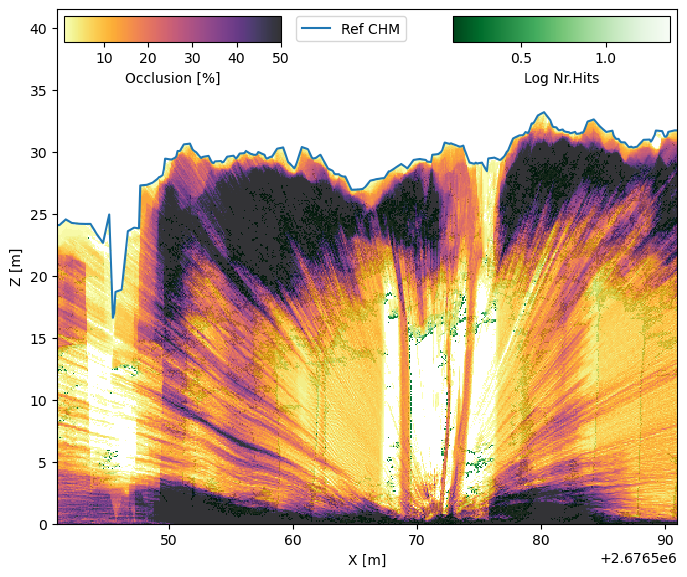

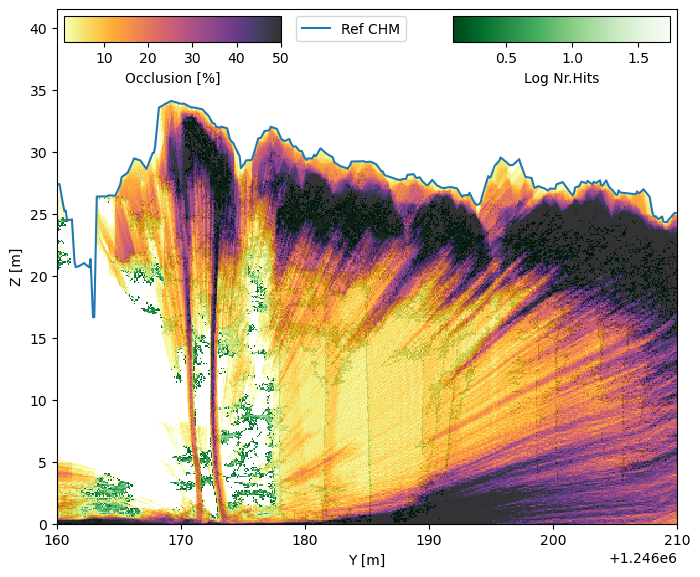

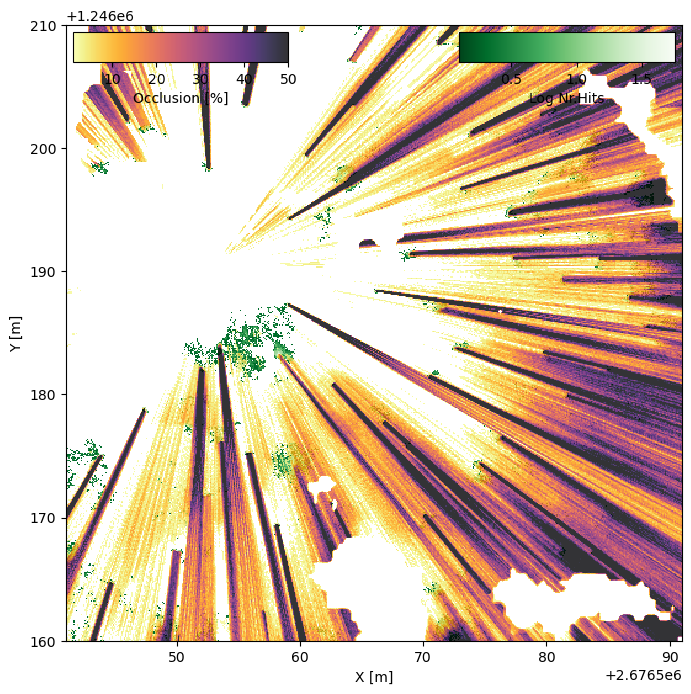

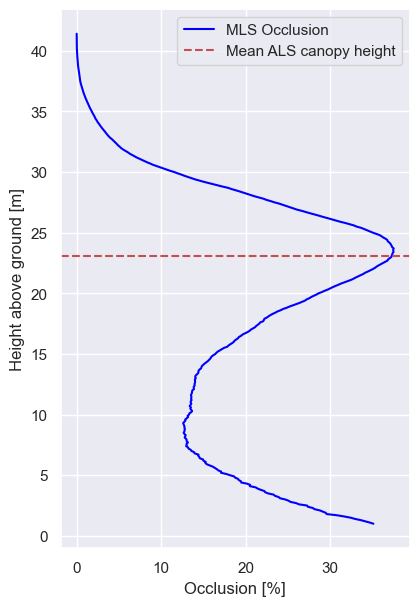

In [6]:
%matplotlib inline
test.get_Occl_TransectFigure(start_ind=200, end_ind=300, axis=0, show_plots=True)
test.get_Occl_TransectFigure(start_ind=200, end_ind=300, axis=1, show_plots=True)
test.get_Occl_TransectFigure(start_ind=50, end_ind=100, axis=2, show_plots=True)
occl_prof = test.get_Occlusion_Profile(show_plots=True)

We can also run this script from the command line. To control your inputs and parameters, edit the JSON accordingly. 
Note that by running the script via the command line, the plots will not be displayed per default but stored in the output folder.

In [7]:
!python Test_Package_TLS.py settings_TLS.JSON

  1% [                    ]
  2% [                    ]
  3% [                    ]
  4% [                    ]
  5% [=                   ]
  6% [=                   ]
  7% [=                   ]
  8% [=                   ]
  9% [=                   ]
 10% [==                  ]
 11% [==                  ]
 12% [==                  ]
 13% [==                  ]
 14% [==                  ]
 15% [===                 ]
 16% [===                 ]
 17% [===                 ]
 18% [===                 ]
 19% [===                 ]
 20% [====                ]
 21% [====                ]
 22% [====                ]
 23% [====                ]
 24% [====                ]
 25% [=====               ]
 26% [=====               ]
 27% [=====               ]
 28% [=====               ]
 29% [=====               ]
 30% [======              ]
 31% [======              ]
 32% [======              ]
 33% [======              ]
 34% [======              ]
 35% [=======             ]
 36% [=======       